                r_pol       r_eq
    normal    25000.0    25590.9
     split    25000.0    25590.4


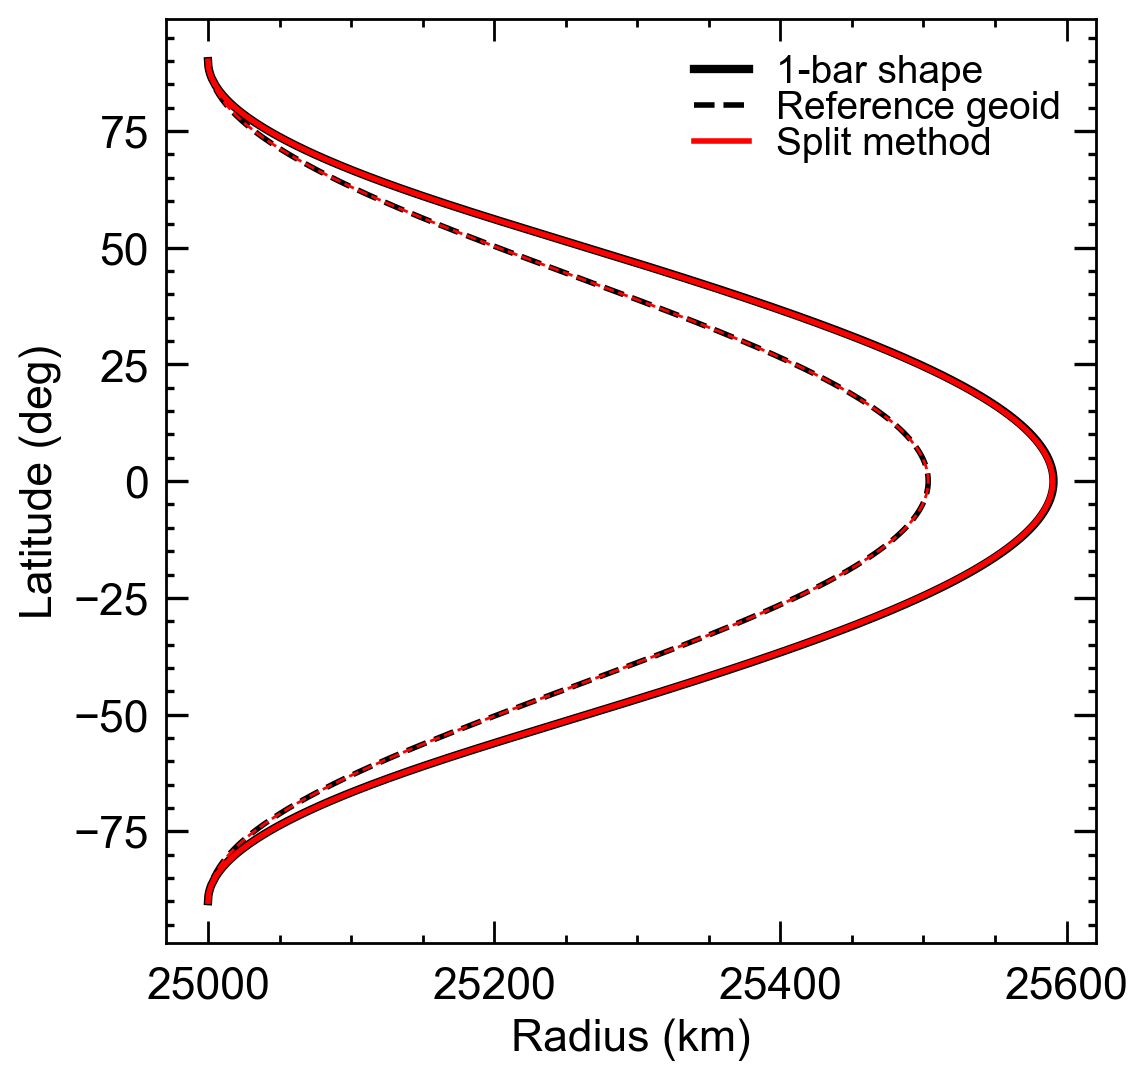

In [1]:
import matplotlib.pyplot as plt
plt.style.use(f'plots.mplstyle')
%config InlineBackend.figure_format = 'retina'

import numpy as np
from scipy.integrate import trapezoid
from importlib import reload

import wind_profiles; reload(wind_profiles)
import geoid; reload(geoid)

# get a callable omega(phi) from observed wind profile, can pass option='symmetric' (default) or option='composite' (an odd profile stitching together Voyager 2 and Keck/Gemini data)
omega = wind_profiles.uranus_omega_tot_interpolant()

# constants for Uranus; French et al. (2024 Icarus) Table 17, Fit 15 (Adopted solution)
r_ref = 25559e5
jn = 3509.291e-6, -35.522e-6, 0.
gm = 5793950.3e15

# fix the polar radius and solve for the shape
r_pol = 25000e5
print(f"{'':>10} {'r_pol':>10} {'r_eq':>10}")
# preferred (slower) method: retain full rotation
g = geoid.geoid(r_pol, jn, r_ref, gm, omega=omega) # note, no presumed rigid rotation period enters the calculation
g0 = geoid.geoid(r_pol, jn, r_ref, gm, omega=np.pi*2/(17.25*3600)) # pass constant "bulk" rotation to construct a rigidly rotating reference geoid
print(f'{"normal":>10} {1e-5*r_pol:10.1f} {1e-5*g.r[len(g.mu) // 2]:10.1f}')
plt.plot(1e-5 * g.r, g.lat, 'k-', lw=3, label='1-bar shape')
plt.plot(1e-5 * g0.r, g0.lat, 'k--', lw=2, label='Reference geoid')

# validate against split method: shape gets contributions from rigid and differential rotation parts; calculate reference geoid and dynamical height separately
g = geoid.geoid_split(r_pol, jn, r_ref, gm, omega_rigid=np.pi*2/(17.25*3600), omega=omega) # alternate method
print(f'{"split":>10} {1e-5*r_pol:10.1f} {1e-5*g.r[len(g.mu) // 2]:10.1f}')
plt.plot(1e-5 * g.r, g.lat, color='r', label='Split method')
plt.plot(1e-5 * g.r_geoid, g.lat, '--', color='r', lw=1)

plt.xlabel(r'Radius (km)')
plt.ylabel(r'Latitude (deg)')
plt.legend(fontsize=14)

    #             r_pol       r_eq
    # normal    25000.0    25590.9
    #  split    25000.0    25590.4


    period      r_pol       r_eq     h_mean  pole-pole 
     15.25    25000.0    25590.6        3.4   0.00e+00
     16.25    25000.0    25590.7       32.3   0.00e+00
     17.25    25000.0    25590.4       55.9   0.00e+00
     18.25    25000.0    25589.8       75.5   0.00e+00


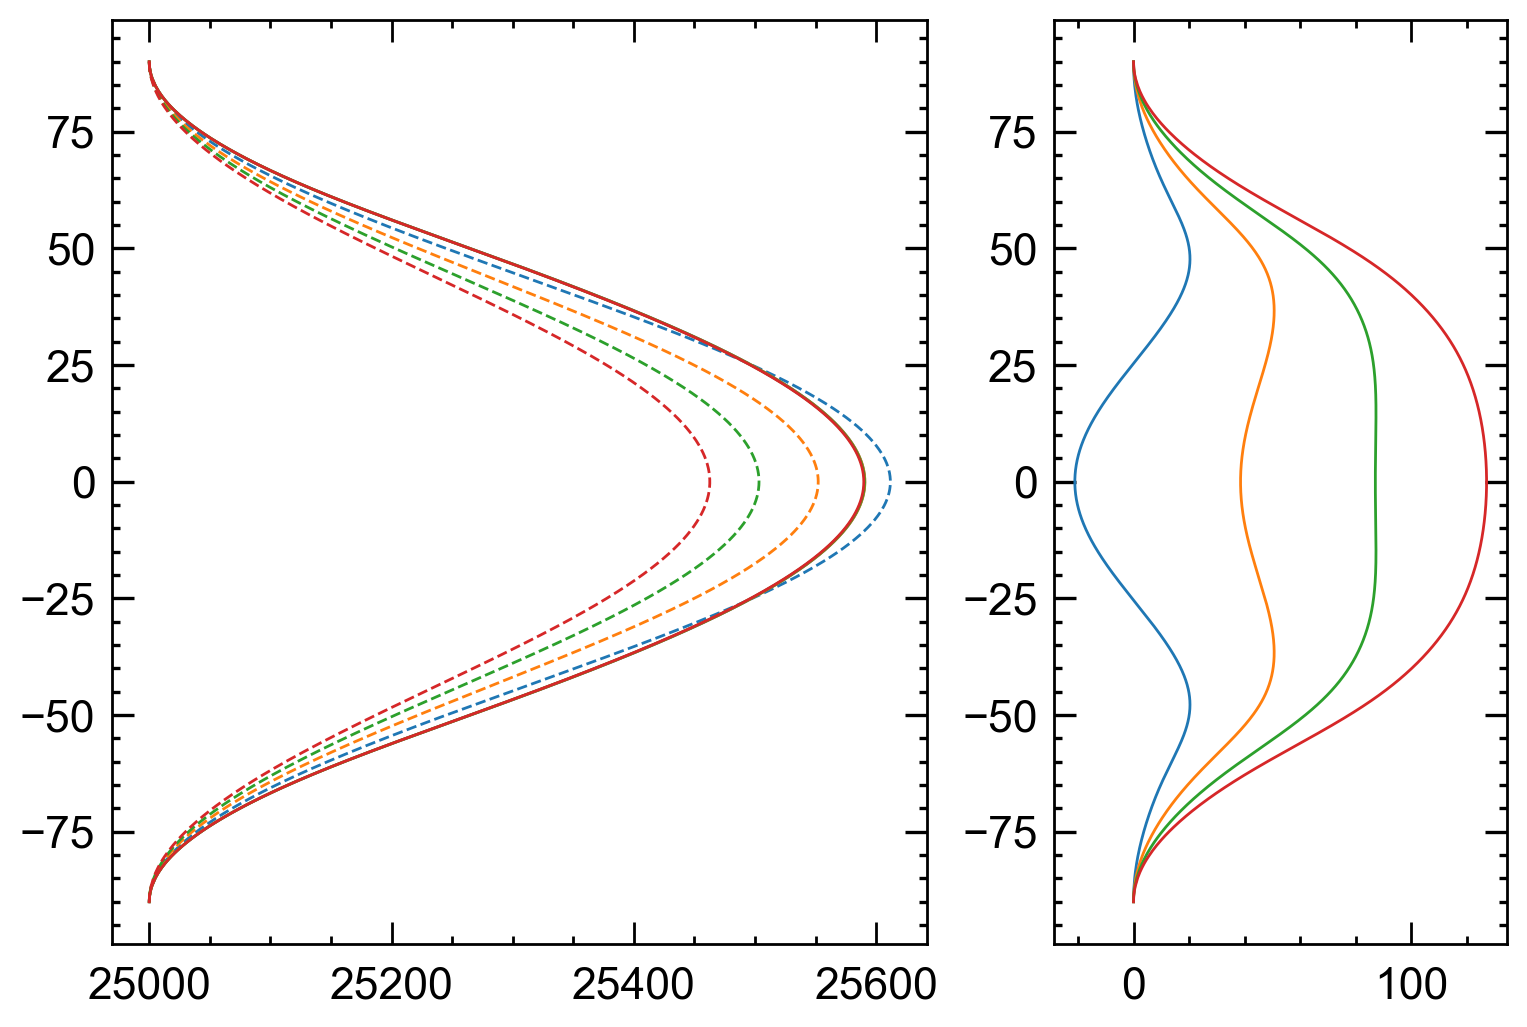

In [2]:
# for split (Lindal) method, different background rotation may yield slightly different shapes, but this is a byproduct of the numerical construction.
# including any conversion between angular velocity and linear velocity can introduce discrepancies, because such a conversion involves
# the distance to the rotation axis. this distance is dependent on the shape of the reference geoid, which can be different from that of the final model.

# now that the total rotation profile is specified, the overall error (here in r_eq) is down to a few hundred meters over the 3-hour range of rotation periods considered.
# in previous versions where we were involving even more conversions from angular angular to linear velocity, this error was around 6 km.
print(f"{'period':>10} {'r_pol':>10} {'r_eq':>10} {'h_mean':>10} {'pole-pole':>10} ")
fig, ax = plt.subplots(1, 2, figsize=(9, 6), gridspec_kw={'width_ratios':(9,5)})
periods = 15.25, 16.25, 17.25, 18.25 # 3-hour range
for ip, p_rot_h in enumerate(periods):
    omega_rigid = np.pi*2/(p_rot_h*3600)
    g = geoid.geoid_split(r_pol, jn, r_ref, gm, omega_rigid=omega_rigid, omega=omega)

    r_eq = g.r[len(g.mu) // 2]
    pole_to_pole = g.r[-1] - g.r[0] # should be zero if integration is accurate and wind profile is north-south symmetric
    print(f'{p_rot_h:10.2f} {1e-5*r_pol:10.1f} {1e-5*r_eq:10.1f} {1e-5 * g.h_mean:10.1f} {1e-5*pole_to_pole:10.2e}')

    ax[0].plot(1e-5 * g.r_geoid, g.lat, '--', color=f'C{ip}', lw=1)
    ax[0].plot(1e-5 * g.r, g.lat, '-', color=f'C{ip}', lw=1)
    ax[1].plot(1e-5 * g.h, g.lat, '-', color=f'C{ip}', lw=1)

# the integral version that retains the full latitude-dependent Omega (as in Lindal 1992 AJ or Galanti et al. 2023 GRL) shows that r_pol is uniquely specified by the equatorial (or any) radius.

    # period      r_pol       r_eq     h_mean  pole-pole 
    #  15.25    25000.0    25590.6        3.4   0.00e+00
    #  16.25    25000.0    25590.7       32.3   0.00e+00
    #  17.25    25000.0    25590.4       55.9   0.00e+00
    #  18.25    25000.0    25589.8       75.5   0.00e+00


rmse = 0.5 km
    period      r_pol r_eq_geoid       r_eq     h_mean
     15.25    24968.4  25577.845  25557.116       3.42
     16.25    24968.4  25518.616  25557.116      32.21
     17.25    24968.4  25470.017  25557.116      55.91
     18.25    24968.4  25429.619  25557.116      75.66


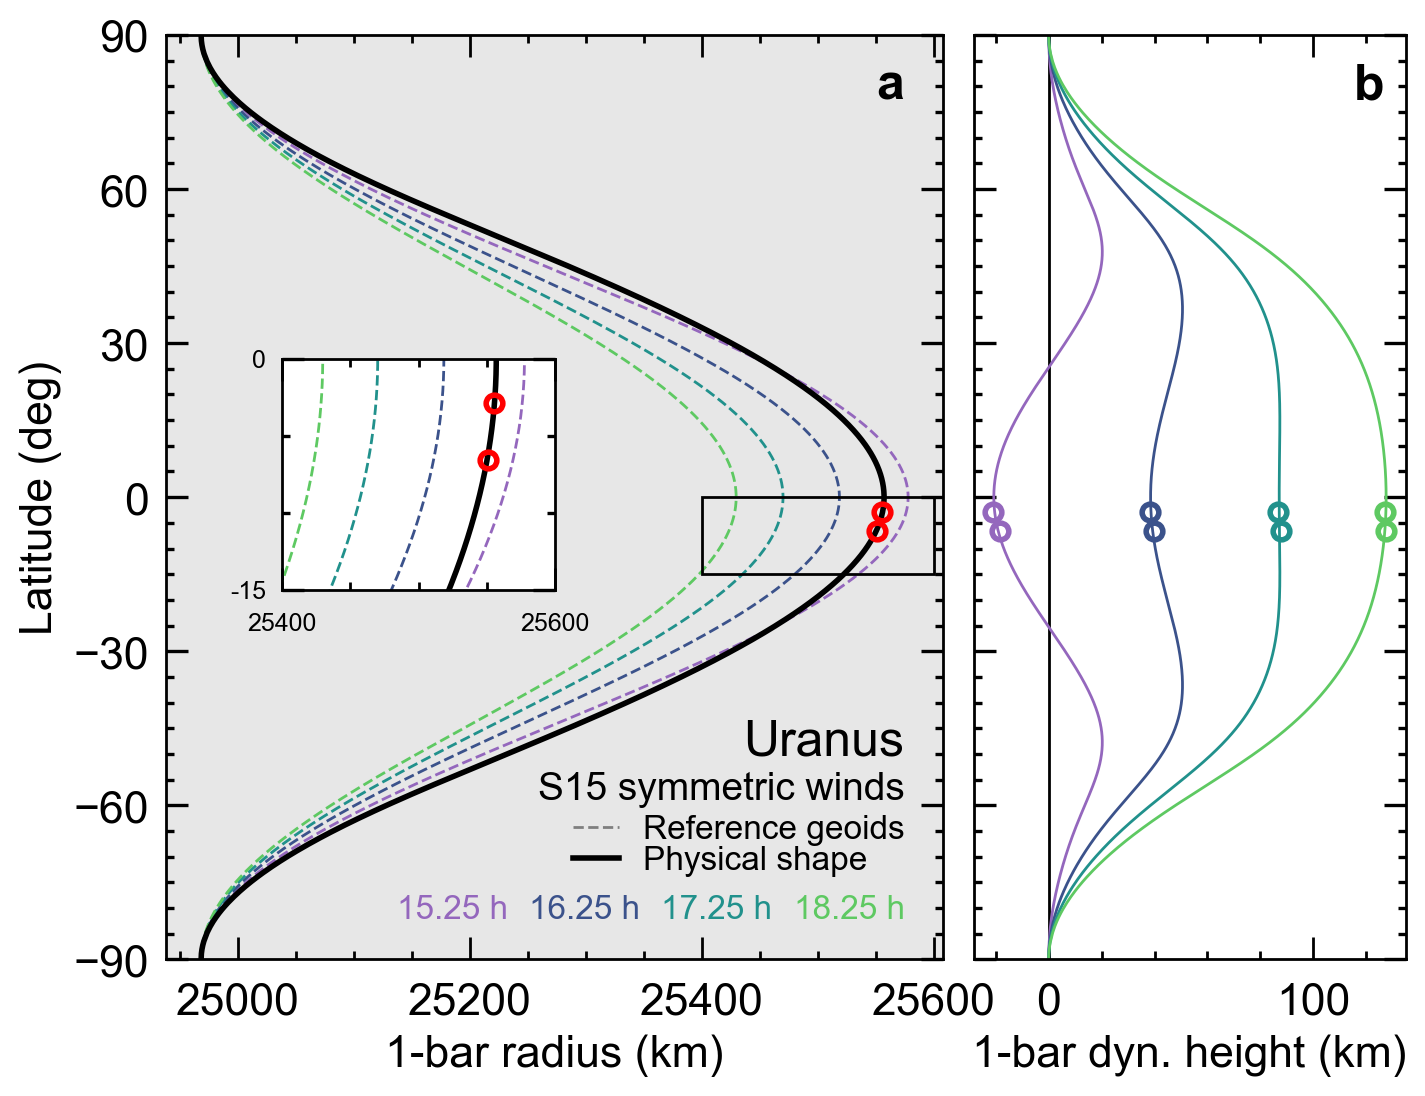

In [ ]:
from occultation_data import uranus as occultation_radii

# main shape model plot for paper
from matplotlib.patches import Rectangle
def shape_plot(skip_inset_eq=False, inset_xlim=(25400, 25600)):    
    fig, ax = plt.subplots(1, 2, figsize=(8, 6), gridspec_kw={'width_ratios':(9, 5), 'wspace':0.05})
    if not skip_inset_eq: # inset near equator
        inset_xlim = inset_xlim
        ax_inset_eq = ax[0].inset_axes([0.15, 0.4, 0.35, 0.25], xlim=inset_xlim, ylim=(-15, 0), xticklabels=[], yticklabels=[])
        ax[0].add_artist(Rectangle((inset_xlim[0], -15), inset_xlim[1]-inset_xlim[0], 15, facecolor='none', edgecolor='k', lw=1, zorder=2))
        xticks = np.linspace(inset_xlim[0], inset_xlim[1], 5)
        ax_inset_eq.set_xticks(xticks, minor=True)
        ax_inset_eq.set_xticks([inset_xlim[0], inset_xlim[1]], [inset_xlim[0], inset_xlim[1]], minor=False, fontsize=9)
        ax_inset_eq.set_yticks([-15, -10, -5, 0], minor=True)
        ax_inset_eq.set_yticks([-15, 0], [-15, 0], minor=False, fontsize=9)
        ax_inset_eq.set_xlim(*inset_xlim)

    yl = -90, 90 # ax[1].get_ylim()
    ax[1].vlines(0, *yl, color='k', linewidth=1, zorder=-1)
    for z in ax:
        z.set_yticks(np.linspace(-90, 90, 7), minor=False)
        z.set_yticks(np.linspace(-90, 90, 37), minor=True)
        z.set_ylim(*yl)
    ax[1].tick_params(labelleft=False)
    ax[0].set_ylabel('Latitude (deg)')
    # ax[0].set_xlabel('100-mbar radius (km)')
    # ax[1].set_xlabel('100-mbar dyn. height (km)')
    ax[0].set_xlabel('1-bar radius (km)')
    ax[1].set_xlabel('1-bar dyn. height (km)')
    ax[0].set_facecolor('#e7e7e7')

    if skip_inset_eq:
        return ax
    else:
        return ax, ax_inset_eq

ax, ax_inset = shape_plot()

reload(geoid)
from scipy.optimize import minimize_scalar
omega = wind_profiles.uranus_omega_tot_interpolant()

if False: # fit just point closest to the equator
    r_pol = 25000e5
    for i in range(10):
        g = geoid.geoid(r_pol, jn, r_ref, gm, omega=omega) # note, no presumed rigid rotation period enters the calculation

        # compare to data and adjust r_pol
        latitude, radius = occultation_radii['voyager 2 ingress']
        error_km = radius - np.interp(latitude, g.lat[::-1], 1e-5 * g.r[::-1])
        if abs(error_km) < 0.001: break
        r_pol += 1e5 * error_km
    else:
        raise RuntimeError('failed in iterations to fit occultations')
else: # find r_pol that minimizes rms radius error of both occultations
    def get_rmse(x):
        r_pol = x * 1e9
        g = geoid.geoid(r_pol, jn, r_ref, gm, omega=omega)
        squared_errors = np.array([ (_r - np.interp(_lat, g.lat[::-1], 1e-5 * g.r[::-1])) ** 2 for occ, (_lat, _r) in occultation_radii.items()])
        return np.sqrt(np.mean(squared_errors))
    sol = minimize_scalar(get_rmse, bracket=np.array([2, 3]), method='brent', options={'xtol':1e-6})
    print(f'rmse = {sol.fun:.1f} km')
    r_pol = sol.x * 1e9

    # get final shape for optimized r_pol
    g = geoid.geoid(r_pol, jn, r_ref, gm, omega=omega)

# ax, ax_inset_eq, ax_inset_pol = plot(g, color='k', suppress_legend=True, skip_inset_pol=False, width_ratios=(9, 5), xlim_inset_pol=(24970, 24980))
ax[0].plot(1e-5 * g.r, g.lat, 'k-')
ax_inset.plot(1e-5 * g.r, g.lat, 'k-')
for occ, (latitude, radius) in occultation_radii.items():
    ax[0]   .plot(radius, latitude, 'ro', mfc='none', mew=2)
    ax_inset.plot(radius, latitude, 'ro', mfc='none', mew=2)

# reference geoids depend on rigid rotation; loop through them now
print(f"{'period':>10} {'r_pol':>10} {'r_eq_geoid':>10} {'r_eq':>10} {'h_mean':>10}")
for ip, p_rot_h in enumerate(periods):
    
    r_pol = g.r[0]
    r_eq = g.r[len(g.mu) // 2]
    g_ref = geoid.geoid(r_pol, jn, r_ref, gm, omega=np.pi*2/(p_rot_h*3600))
    r_eq_ref = g_ref.r[len(g_ref.mu) // 2]
    
    color = 'tab:purple' if ip == 0 else plt.get_cmap()(1. * (ip) / 4)

    ax[0].plot(1e-5 * g_ref.r, g.lat, '--', color=color, lw=1, zorder=0)
    ax_inset.plot(1e-5 * g_ref.r, g.lat, '--', color=color, lw=1)

    h = g.r - g_ref.r
    h_mean = -1. / 180 * trapezoid(h, x=g.lat)

    ax[1].plot(1e-5 * h, g.lat, '-', color=color, lw=1)
    for occ, (latitude, radius) in occultation_radii.items():
        ax[1].plot(np.interp(latitude, g.lat[::-1], radius - 1e-5 * g_ref.r[::-1]), latitude, 'o', color=color, mfc='none', mew=2)

    ax[0].text(0.44 + 0.17 * ip, 0.07, f'{p_rot_h:.2f} h', color=color, fontsize=12, ha='right', va='top', transform=ax[0].transAxes)
    print(f'{p_rot_h:10.2f} {1e-5*r_pol:10.1f} {1e-5*r_eq_ref:10.3f} {1e-5*r_eq:10.3f} {1e-5 * h_mean:10.2f}')

    if True: # save reference geoid output to disk
        outfile = f'models/uranus_model_symmetric_wind_reference_geoid_{p_rot_h:.2f}h.txt'
        header  = f"detailed model output for Uranus's 1-bar reference geoid, assuming rigid rotation with period {p_rot_h:.2f} h.\n"
        header += "see uranus_model_symmetric_wind.txt for the corresponding shape model including the effect of the latitudinally varying atmospheric rotation.\n"
        header += 'that model used the symmetric wind profile from Sromovsky et al. (2015, Icarus 258) Equation (2) and this reference geoid satisfies the same r_pol.\n'
        header += 'mu=sin(phi), phi [radians], and lat_deg [degrees] refer to planetocentric latitude; lat_pg_deg gives planetographic latitude in degrees.\n'
        # header += f"{'index':>5} {'r_pol_km':>16} {'r_eq_km':>16}"
        fmt = '%16.5f', '%16.5f', '%16.5f', '%16.5f', '%16.5f', '%16.5f', '%16.3f', 
        names = 'mu', 'phi_rad', 'lat_deg', 'lat_pg_deg', 'psi_rad', 'omega_rad_s-1', 'r_km'
        for name in names:
            header += f"{name:>16} "
        data = np.array([g_ref.mu, g_ref.phi, g_ref.lat, g_ref.planetographic_latitude, g_ref.psi, np.pi*2/(p_rot_h*3600) * np.ones_like(g_ref.mu), 1e-5 * g_ref.r]).T
        np.savetxt(outfile, data, fmt=fmt, header=header, comments='')

ax[0].plot([], '--', color='tab:grey', lw=1, label='Reference geoids')
# ax[0].plot([], 'k-', lw=1, label='Isobaric surface')
ax[0].plot([], 'k-', label='Physical shape')
ax[0].legend(loc=4, bbox_to_anchor=(0.988, 0.057), fontsize=12)
ax[0].text(0.95, 0.21, 'Uranus', ha='right', va='bottom', fontsize=18, transform=ax[0].transAxes)
ax[0].text(0.95, 0.165, 'S15 symmetric winds', ha='right', va='bottom', fontsize=14, transform=ax[0].transAxes)

for iax, c in enumerate('ab'):
    ax[iax].text(0.95, 0.97, c, weight='bold', fontsize=18, ha='right', va='top', transform=ax[iax].transAxes)

if True: # save model output to disk
    outfile = 'models/uranus_model_symmetric_wind.txt'
    header  = "detailed model output for Uranus's 1-bar isobaric surface. models are described in Mankovich et al. 2026, PSJ.\n"
    header += 'this model assumes the symmetric wind profile from Sromovsky et al. (2015, Icarus 258) Equation (2).\n'
    header += 'mu=sin(phi), phi [radians], and lat_deg [degrees] refer to planetocentric latitude; lat_pg_deg gives planetographic latitude in degrees.\n'
    # header += f"{'index':>5} {'r_pol_km':>16} {'r_eq_km':>16}"
    fmt = '%16.5f', '%16.5f', '%16.5f', '%16.5f', '%16.5f', '%16.5f', '%16.3f', 
    names = 'mu', 'phi_rad', 'lat_deg', 'lat_pg_deg', 'psi_rad', 'omega_rad_s-1', 'r_km'
    for name in names:
        header += f"{name:>16} "
    data = np.array([g.mu, g.phi, g.lat, g.planetographic_latitude, g.psi, g.omega, 1e-5 * g.r]).T
    np.savetxt(outfile, data, fmt=fmt, header=header, comments='')

plt.savefig('figures/uranus_optimize_rpol.pdf')
plt.savefig('figures/uranus_optimize_rpol.png')

    # period      r_pol r_eq_geoid       r_eq     h_mean
    #  15.25    24968.4  25577.845  25557.116       3.42
    #  16.25    24968.4  25518.616  25557.116      32.21
    #  17.25    24968.4  25470.017  25557.116      55.91
    #  18.25    24968.4  25429.619  25557.116      75.66


    period      r_pol       r_eq     h_mean  pole-pole       rmse
     15.25    24968.7    25557.1        3.3   0.00e+00        0.5
     16.25    24968.6    25557.1       32.1   0.00e+00        0.5
     17.25    24968.9    25557.1       55.6   0.00e+00        0.5
     18.25    24969.4    25557.1       75.1   0.00e+00        0.5


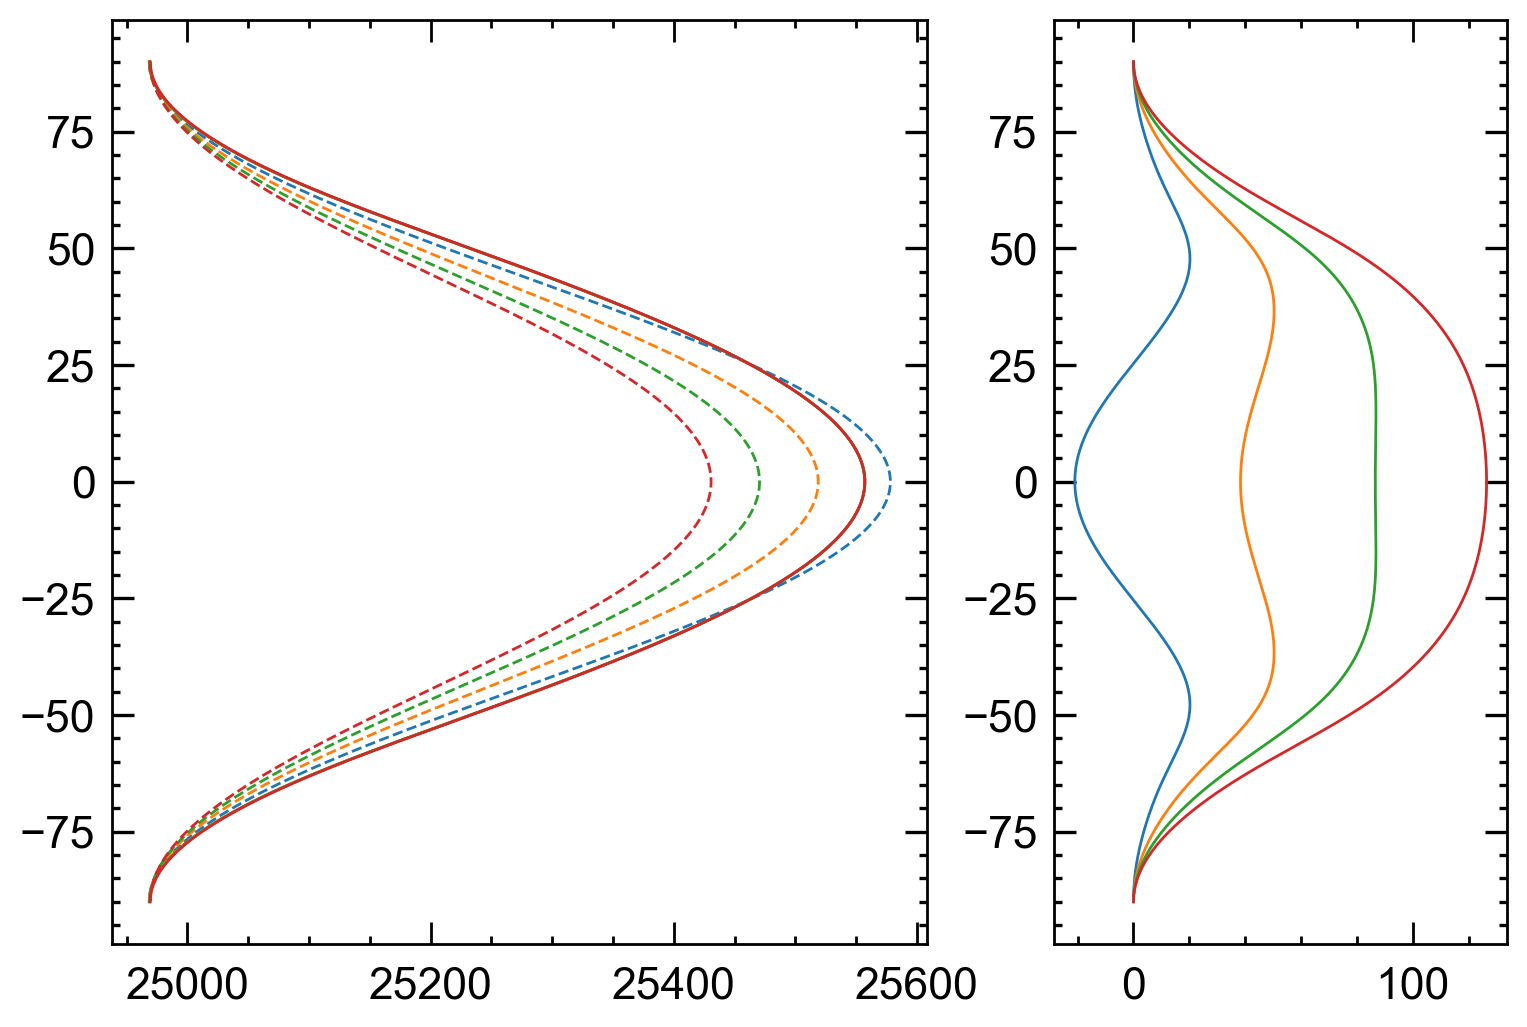

In [4]:
# for comparison with main result, do optimization to occultation using the alternative split method described in Section 2.2
print(f"{'period':>10} {'r_pol':>10} {'r_eq':>10} {'h_mean':>10} {'pole-pole':>10} {'rmse':>10}")
fig, ax = plt.subplots(1, 2, figsize=(9, 6), gridspec_kw={'width_ratios':(9,5)})
for ip, p_rot_h in enumerate(periods):
    omega_rigid = np.pi*2/(p_rot_h*3600)

    if False: # fit near-equatorial point
        r_pol = 25000e5
        for i in range(10):
            # geoid_split() takes both omega_rigid (the uniform spin of the reference geoid) and omega (a callable giving the full atmospheric rotation, omega(phi))
            g = geoid.geoid_split(r_pol, jn, r_ref, gm, omega_rigid=omega_rigid, omega=omega)

            # compare to data and adjust r_pol
            latitude, radius = occultation_radii['voyager 2 ingress']
            error_km = radius - np.interp(latitude, g.lat[::-1], 1e-5 * g.r[::-1])
            # print(i, r_pol, error_km)
            if abs(error_km) < 0.001: break
            r_pol += 1e5 * error_km
        else:
            raise RuntimeError('failed in iterations to fit occultations')
    else: # fit rms error
        from scipy.optimize import minimize
        def get_rmse(x):
            r_pol = x * 1e9
            # geoid_split() takes both omega_rigid (the uniform spin of the reference geoid) and omega (a callable giving the full atmospheric rotation, omega(phi))
            g = geoid.geoid_split(r_pol, jn, r_ref, gm, omega_rigid=omega_rigid, omega=omega) 
            squared_errors = np.array([ (_r - np.interp(_lat, g.lat[::-1], 1e-5 * g.r[::-1])) ** 2 for occ, (_lat, _r) in occultation_radii.items()])
            return np.sqrt(np.mean(squared_errors))
        sol = minimize_scalar(get_rmse, bracket=np.array([2, 3]), method='brent', options={'xtol':1e-6})
        r_pol = sol.x * 1e9

        # get final shape for optimized r_pol
        g = geoid.geoid_split(r_pol, jn, r_ref, gm, omega_rigid=omega_rigid, omega=omega)

    r_eq = g.r[len(g.mu) // 2]
    pole_to_pole = g.r[-1] - g.r[0] # should be zero if integration is accurate and wind profile is north-south symmetric
    print(f'{p_rot_h:10.2f} {1e-5*r_pol:10.1f} {1e-5*r_eq:10.1f} {1e-5 * g.h_mean:10.1f} {1e-5*pole_to_pole:10.2e} {sol.fun:10.1f}')

    ax[0].plot(1e-5 * g.r_geoid, g.lat, '--', color=f'C{ip}', lw=1)
    ax[0].plot(1e-5 * g.r, g.lat, '-', color=f'C{ip}', lw=1)
    ax[1].plot(1e-5 * g.h, g.lat, '-', color=f'C{ip}', lw=1)

    # period      r_pol       r_eq     h_mean  pole-pole       rmse
    #  15.25    24968.7    25557.1        3.3   0.00e+00        0.5
    #  16.25    24968.6    25557.1       32.1   0.00e+00        0.5
    #  17.25    24968.9    25557.1       55.6   0.00e+00        0.5
    #  18.25    24969.4    25557.1       75.1   0.00e+00        0.5


    period      r_pol       r_eq     h_mean    ell_vol   rmse_ref   rmse_act
     15.25    24950.0    25537.4       3.41  6.816e+28        1.2       19.7
     16.25    25005.1    25596.4      32.40  6.862e+28        0.8       39.2
     17.25    25051.1    25645.5      56.68  6.901e+28        0.6       88.4
     18.25    25089.9    25687.0      77.21  6.934e+28        0.3      129.8


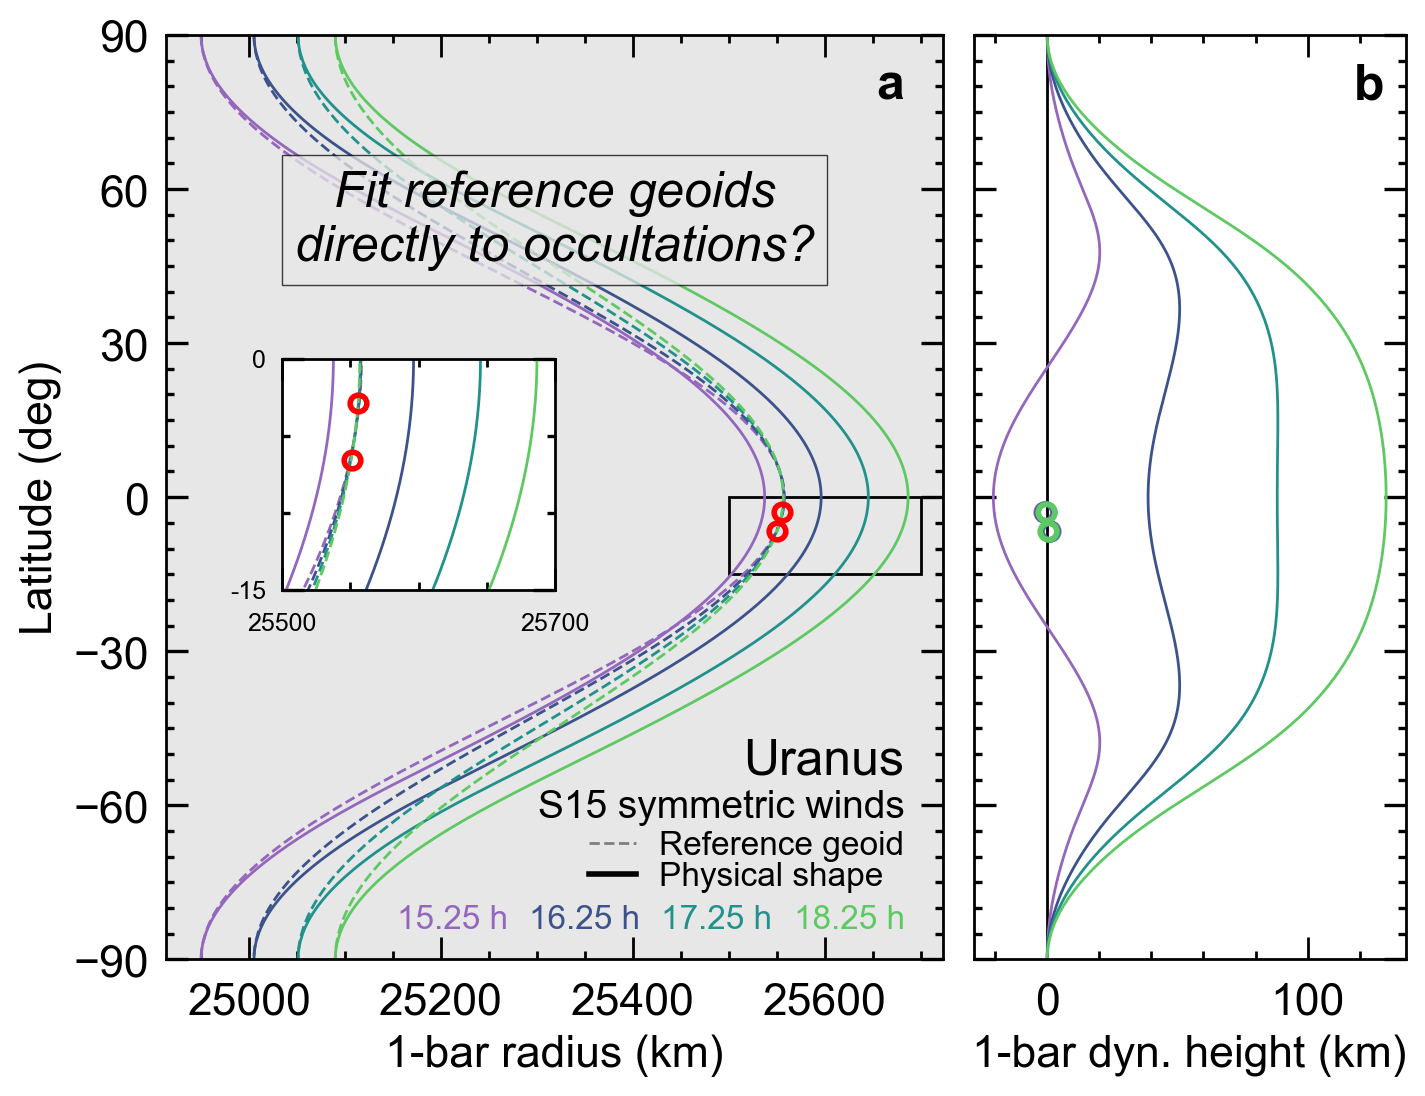

In [5]:
# here incorrectly fit the rigidly rotating *reference geoids* to the occultations instead

ax, ax_inset = shape_plot(inset_xlim=(25500, 25700))

reload(geoid)
print(f"{'period':>10} {'r_pol':>10} {'r_eq':>10} {'h_mean':>10} {'ell_vol':>10} {'rmse_ref':>10} {'rmse_act':>10}")

for ip, p_rot_h in enumerate(periods):
    if False: # fit only the near-equatorial point
        r_pol = 25000e5
        for i in range(10):
            g_ref = geoid.geoid(r_pol, jn, r_ref, gm, omega=np.pi*2/(p_rot_h*3600))

            # compare to data and adjust r_pol
            latitude, radius = occultation_radii['voyager 2 ingress']
            error_km = radius - np.interp(latitude, g.lat[::-1], 1e-5 * g_ref.r[::-1])
            if abs(error_km) < 0.001: break
            r_pol += 1e5 * error_km
        else:
            raise RuntimeError('failed in iterations to fit occultations')
    else: # fit rms error for two occultations
        def get_rmse(x):
            r_pol = x * 1e9
            g_ref = geoid.geoid(r_pol, jn, r_ref, gm, omega=np.pi*2/(p_rot_h*3600)) # rigidly rotating reference geoid
            squared_errors = np.array([ (_r - np.interp(_lat, g_ref.lat[::-1], 1e-5 * g_ref.r[::-1])) ** 2 for occ, (_lat, _r) in occultation_radii.items()])
            return np.sqrt(np.mean(squared_errors))
        sol = minimize_scalar(get_rmse, bracket=np.array([2, 3]), method='brent', options={'xtol':1e-6})
        rmse = sol.fun
        # print(f'rmse = {sol.fun:.1f} km')
        r_pol = sol.x * 1e9
        g_ref = geoid.geoid(r_pol, jn, r_ref, gm, omega=np.pi*2/(p_rot_h*3600)) # final reference geoid for best-fitting r_pol

    # full isobaric shape, including the effect of the winds, for this same polar radius
    g = geoid.geoid(r_pol, jn, r_ref, gm, omega=omega)
    r_pol = g.r[0]
    r_eq = g.r[len(g.mu) // 2]

    # get actual rmse error relative to the physical isobaric surface -- it will be large
    rmse_act = np.sqrt(np.mean(np.array([ (_r - np.interp(_lat, g.lat[::-1], 1e-5 * g.r[::-1])) ** 2 for occ, (_lat, _r) in occultation_radii.items()])))

    color = 'tab:purple' if ip == 0 else plt.get_cmap()(1. * (ip) / 4)

    ax[0].plot(1e-5 * g.r, g.lat, '-', color=color, lw=1)
    ax[0].plot(1e-5 * g_ref.r, g.lat, '--', color=color, lw=1)
    ax_inset.plot(1e-5 * g.r, g.lat, '-', color=color, lw=1)
    ax_inset.plot(1e-5 * g_ref.r, g.lat, '--', color=color, lw=1)

    h = g.r - g_ref.r
    h_mean = -1. / 180 * trapezoid(h, x=g.lat)

    # volume enclosed by this isobar in the ellipsoidal approximation
    volume = 4. * np.pi / 3 * r_eq ** 2 * r_pol

    ax[1].plot(1e-5 * h, g.lat, '-', color=color, lw=1)
    for occ, (latitude, radius) in occultation_radii.items():
        ax[1].plot(np.interp(latitude, g.lat[::-1], radius - 1e-5 * g_ref.r[::-1]), latitude, 'o', color=color, mfc='none', mew=2)

    ax[0].text(0.44 + 0.17 * ip, 0.06, f'{p_rot_h:.2f} h', color=color, fontsize=12, ha='right', va='top', transform=ax[0].transAxes)
    print(f'{p_rot_h:10.2f} {1e-5*r_pol:10.1f} {1e-5*r_eq:10.1f} {1e-5 * h_mean:10.2f} {volume:10.3e} {rmse:10.1f} {rmse_act:10.1f}')

for occ, (latitude, radius) in occultation_radii.items():
    ax[0]   .plot(radius, latitude, 'ro', mfc='none', mew=2)
    ax_inset.plot(radius, latitude, 'ro', mfc='none', mew=2)

ax[0].plot([], '--', color='tab:grey', lw=1, label='Reference geoid')
# ax[0].plot([], 'k-', lw=1, label='Isobaric surface')
ax[0].plot([], 'k-', label='Physical shape')
ax[0].legend(loc=4, bbox_to_anchor=(0.988, 0.04), fontsize=12)
ax[0].text(0.95, 0.19, 'Uranus', ha='right', va='bottom', fontsize=18, transform=ax[0].transAxes)
ax[0].text(0.95, 0.145, 'S15 symmetric winds', ha='right', va='bottom', fontsize=14, transform=ax[0].transAxes)

fig = plt.gcf()
ax[0].text(0.5, 0.8, 'Fit reference geoids\ndirectly to occultations?', ha='center', va='center', fontsize=18, transform=ax[0].transAxes, style='italic')
xc, yc = 0.5, 0.8
xw, yw = 0.7, 0.14
yb = yc - yw / 2
xl = xc - xw / 2
ax[0].add_artist(Rectangle((xl, yb), xw, yw, facecolor='#e7e7e7', edgecolor='k', lw=0.5, zorder=2, alpha=0.75, transform=ax[0].transAxes))

for iax, c in enumerate('ab'):
    ax[iax].text(0.95, 0.97, c, weight='bold', fontsize=18, ha='right', va='top', transform=ax[iax].transAxes)

plt.savefig('figures/uranus_optimize_rpol_ignore_winds.pdf')

    # period      r_pol       r_eq     h_mean    ell_vol   rmse_ref   rmse_act
    #  15.25    24950.0    25537.4       3.41  6.816e+28        1.2       19.7
    #  16.25    25005.1    25596.3      32.40  6.862e+28        0.8       39.2
    #  17.25    25051.1    25645.5      56.68  6.901e+28        0.6       88.4
    #  18.25    25089.9    25687.0      77.21  6.934e+28        0.3      129.8


In [6]:
''' minimize the dynamical height as a function of Omega_0 '''

reload(geoid)
print(f"{'period':>10} {'r_pol':>10} {'r_eq':>10} {'h_mean':>10}")

if False: # fit only near-equatorial point
    r_pol = 25000e5
    for i in range(10):
        g = geoid.geoid(r_pol, jn, r_ref, gm, omega=omega) # note, no presumed rigid rotation period enters the calculation

        # compare to data and adjust r_pol
        latitude, radius = occultation_radii['voyager 2 ingress']
        error_km = radius - np.interp(latitude, g.lat[::-1], 1e-5 * g.r[::-1])
        if abs(error_km) < 0.001: break
        r_pol += 1e5 * error_km
    else:
        raise RuntimeError('failed in iterations to fit occultations')
else: # fit rmse of two occultations
    from scipy.optimize import minimize
    def get_rmse(x):
        r_pol = x * 1e9
        g = geoid.geoid(r_pol, jn, r_ref, gm, omega=omega)
        squared_errors = np.array([ (_r - np.interp(_lat, g.lat[::-1], 1e-5 * g.r[::-1])) ** 2 for occ, (_lat, _r) in occultation_radii.items()])
        return np.sqrt(np.mean(squared_errors))
    sol = minimize_scalar(get_rmse, bracket=np.array([2, 3]), method='brent', options={'xtol':1e-6})
    print(f'rmse = {sol.fun:.1f} km')
    r_pol = sol.x * 1e9

    # get final shape for optimized r_pol
    g = geoid.geoid(r_pol, jn, r_ref, gm, omega=omega)

# solve for the reference geoid rotation period that minimizes the dynamical height
def zero_me(p_rot_h):
    g_ref = geoid.geoid(g.r[0], jn, r_ref, gm, omega=np.pi*2/(p_rot_h*3600))
    h = g.r - g_ref.r
    h_mean = -1. / 180 * trapezoid(h, x=g.lat)
    print(f'{p_rot_h[0]:10.2f} {1e-5 * r_pol:10.2f} {1e-5 * r_eq:10.2f} {1e-5 * h_mean:10.2f}')
    return h_mean

from scipy.optimize import root
sol = root(zero_me, 17.25)
print(sol)
print(sol.x[0]) # 15.14 h


    period      r_pol       r_eq     h_mean
rmse = 0.5 km
     17.25   24968.44   25687.01      55.91
     17.25   24968.44   25687.01      55.91
     17.25   24968.44   25687.01      55.91
     17.25   24968.44   25687.01      55.91
     14.66   24968.44   25687.01     -16.66
     15.25   24968.44   25687.01       3.51
     15.15   24968.44   25687.01       0.18
     15.14   24968.44   25687.01      -0.00
     15.14   24968.44   25687.01       0.00
     15.14   24968.44   25687.01       0.00
 message: The solution converged.
 success: True
  status: 1
     fun: 3.043562173843384e-07
       x: [ 1.514e+01]
  method: hybr
    nfev: 10
    fjac: [[-1.000e+00]]
       r: [-3.253e+06]
     qtf: [-1.205e-01]
15.143789659174853


rmse = 0.5 km
r_pol_s = 24969.5 km
r_pol_n = 24964.2 km
  r_eq  = 25557.1 km


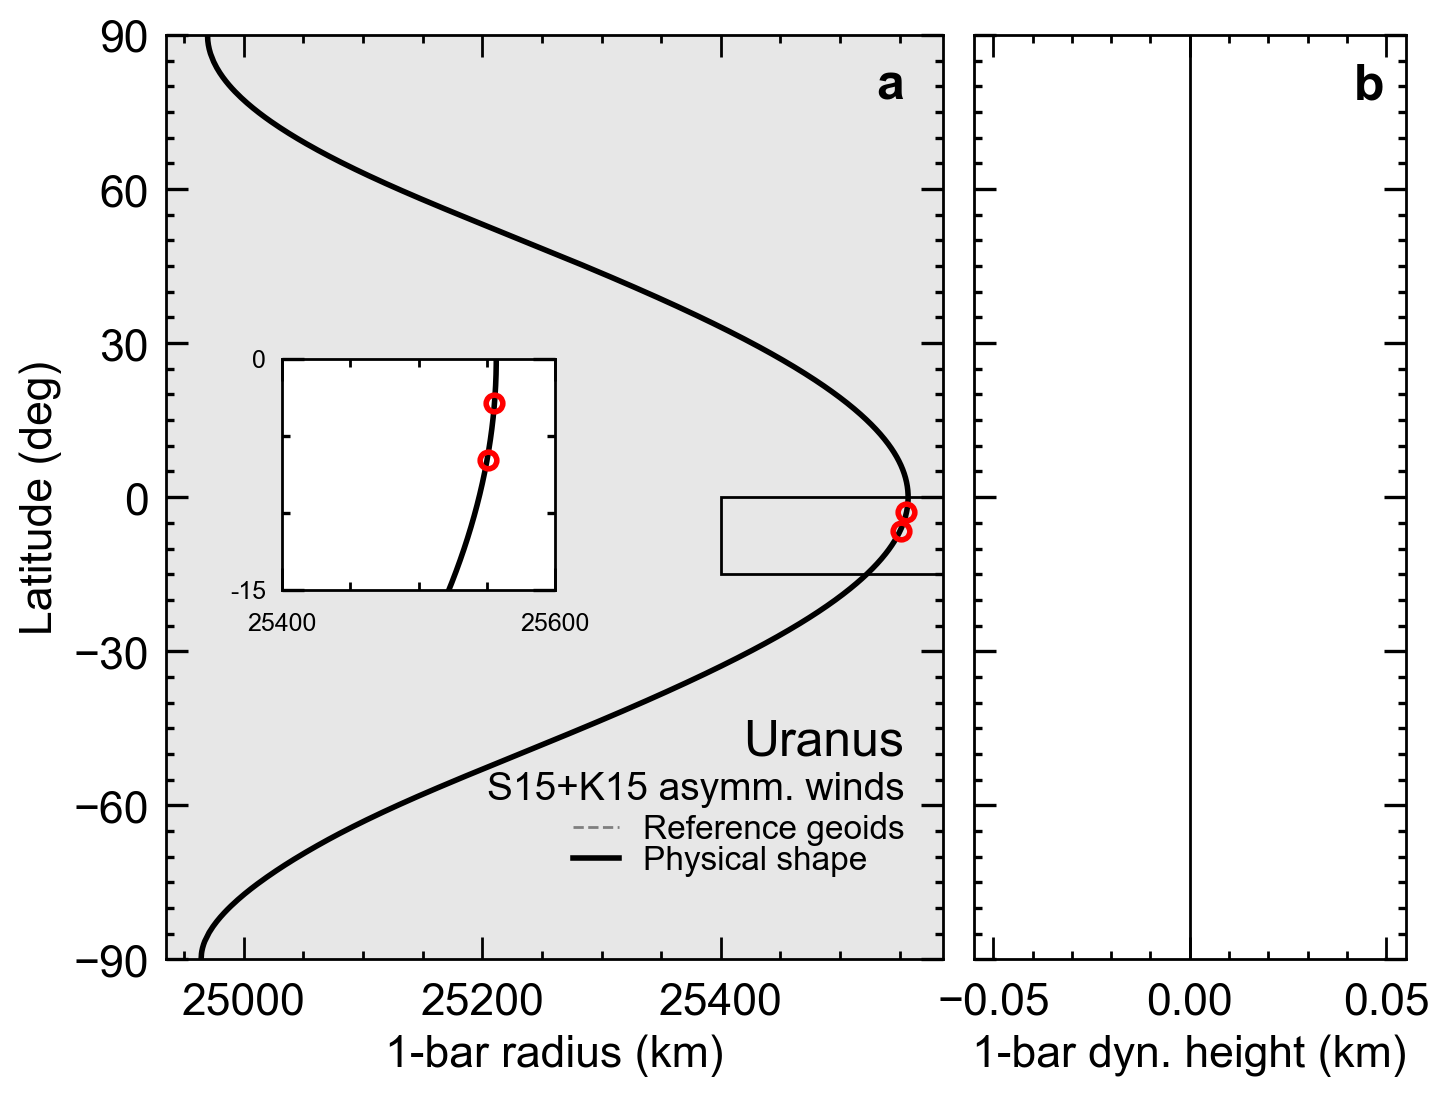

In [7]:
# get best fitting model assuming the 'composite' asymmetric wind profile including Voyager data from Karkoschka 2015 instead of a symmetric fit
ax, ax_inset = shape_plot()

reload(geoid)
from scipy.optimize import minimize_scalar

omega_composite = wind_profiles.uranus_omega_tot_interpolant('composite') # north-south asymmetric wind

def get_rmse(x):
    r_pol = x * 1e9
    g = geoid.geoid(r_pol, jn, r_ref, gm, omega=omega_composite)
    squared_errors = np.array([ (_r - np.interp(_lat, g.lat[::-1], 1e-5 * g.r[::-1])) ** 2 for occ, (_lat, _r) in occultation_radii.items()])
    return np.sqrt(np.mean(squared_errors))
sol = minimize_scalar(get_rmse, bracket=np.array([2, 3]), method='brent', options={'xtol':1e-6})
print(f'rmse = {sol.fun:.1f} km')
r_pol = sol.x * 1e9

# get final shape for optimized r_pol
g = geoid.geoid(r_pol, jn, r_ref, gm, omega=omega_composite)
print(f'r_pol_s = {g.r[0]*1e-5:.1f} km')
print(f'r_pol_n = {g.r[-1]*1e-5:.1f} km')
print(f'  r_eq  = {g.r[len(g.mu) // 2]*1e-5:.1f} km')

# ax, ax_inset_eq, ax_inset_pol = plot(g, color='k', suppress_legend=True, skip_inset_pol=False, width_ratios=(9, 5), xlim_inset_pol=(24970, 24980))
ax[0].plot(1e-5 * g.r, g.lat, 'k-')
ax_inset.plot(1e-5 * g.r, g.lat, 'k-')
for occ, (latitude, radius) in occultation_radii.items():
    ax[0]   .plot(radius, latitude, 'ro', mfc='none', mew=2)
    ax_inset.plot(radius, latitude, 'ro', mfc='none', mew=2)

ax[0].plot([], '--', color='tab:grey', lw=1, label='Reference geoids')
# ax[0].plot([], 'k-', lw=1, label='Isobaric surface')
ax[0].plot([], 'k-', label='Physical shape')
ax[0].legend(loc=4, bbox_to_anchor=(0.988, 0.057), fontsize=12)
ax[0].text(0.95, 0.21, 'Uranus', ha='right', va='bottom', fontsize=18, transform=ax[0].transAxes)
ax[0].text(0.95, 0.165, 'S15+K15 asymm. winds', ha='right', va='bottom', fontsize=14, transform=ax[0].transAxes)

for iax, c in enumerate('ab'):
    ax[iax].text(0.95, 0.97, c, weight='bold', fontsize=18, ha='right', va='top', transform=ax[iax].transAxes)

if True: # save model output to disk
    outfile = 'models/uranus_model_composite_wind.txt'
    header  = "detailed model output for Uranus's 1-bar isobaric surface. models are described in Mankovich et al. 2026, PSJ.\n"
    header += 'this model assumes the composite asymmetric wind profile from Sromovsky et al. (2015, Icarus 258) Table 6.\n'
    header += 'mu=sin(phi), phi [radians], and lat_deg [degrees] refer to planetocentric latitude; lat_pg_deg gives planetographic latitude in degrees.\n'
    # header += f"{'index':>5} {'r_pol_km':>16} {'r_eq_km':>16}"
    fmt = '%16.5f', '%16.5f', '%16.5f', '%16.5f', '%16.5f', '%16.5f', '%16.3f', 
    names = 'mu', 'phi_rad', 'lat_deg', 'lat_pg_deg', 'psi_rad', 'omega_rad_s-1', 'r_km'
    for name in names:
        header += f"{name:>16} "
    data = np.array([g.mu, g.phi, g.lat, g.planetographic_latitude, g.psi, g.omega, 1e-5 * g.r]).T
    np.savetxt(outfile, data, fmt=fmt, header=header, comments='')

# rmse = 0.5 km
# r_pol_s = 24969.5 km
# r_pol_n = 24964.2 km
#   r_eq  = 25557.1 km


In [8]:
# selecting a workable tolerance for solve_ivp.
reload(geoid)
import time
for tol in 1e-11, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6:
    t0 = time.time()
    g = geoid.geoid(r_pol, jn, r_ref, gm, omega=omega, solve_ivp_tol=tol)
    print(tol, 1e-5 * g.r[len(g.mu) // 2], time.time() - t0)

# at 1e-8, a factor of a few faster and still accurate to about 5 m.
# however, testing below for randomized rotation profiles shows that the optimization of r_pol to r_occ can fail to converge with looser tolerances on solve_ivp integration.
# hence, we'll stick to the 1e-10 tolerances.

1e-11 25558.286690043467 1.5573439598083496
1e-10 25558.286668814122 0.013910055160522461
1e-09 25558.28658176723 0.0075299739837646484
1e-08 25558.282717708775 0.005498170852661133
1e-07 25558.273202144606 0.0037338733673095703
1e-06 25558.49892167577 0.0025310516357421875
